# **Data Visualization, Preprocessing, and Statistical Analysis**

**Name:** Umama Azhar
**Course:** (MSCS-634-M50) – Advanced Big Data and Data Mining  
**Assignment:** Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook

# (1) Data Collection

In [3]:
import os

folder = r"C:\Users\Umama\Downloads\Data-Analysis"

os.listdir(folder)

['Supermarket-Sales-Sample-Data.xlsx', 'supermarket.csv']

In [7]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Umama\Downloads\Data-Analysis\supermarket.csv"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
St

In [9]:
# converting the dates and create a helpful numeric column
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Days", "Sales"]].head()

,Order Date,Ship Date,Shipping Days,Sales
0,2017-11-08,2017-11-11,3,261.9600
1,2017-11-08,2017-11-11,3,731.9400
2,2017-06-12,2017-06-16,4,14.6200
3,2016-10-11,2016-10-18,7,957.5775
4,2016-10-11,2016-10-18,7,22.3680


# (2) Data Visualisation 

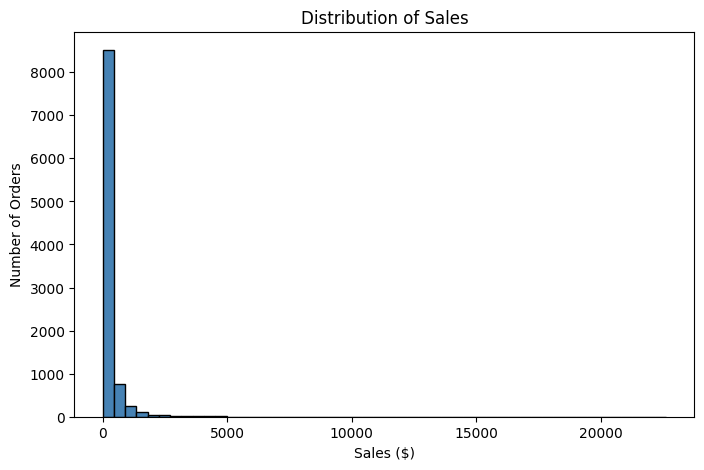

In [10]:
import matplotlib.pyplot as plt

# Histogram: distribution of Sales
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=50, color="steelblue", edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
# The distribution of sales is strongly right-skewed. Most of the roughly 9,800 orders are small, with about 8,500 falling in the first bin 
#(under about $500),while a small number of very large orders stretch the tail out past $20,000. This suggests a few high-value transactions
#may be outliers, which I will examine during preprocessing

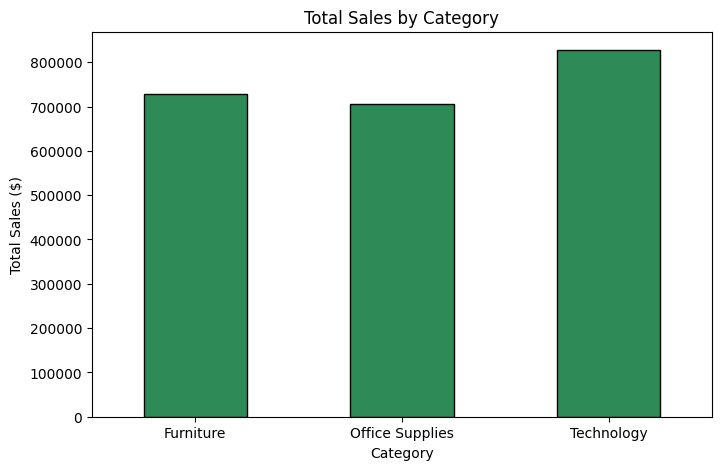

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


In [11]:
# Bar chart: total Sales by Category
sales_by_cat = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8, 5))
sales_by_cat.plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

print(sales_by_cat)

In [ ]:
# Technology generated the highest total sales (about $827,000), followed by Furniture (about $729,000) and Office Supplies (about $705,000). 
#The three categories are fairly close, but Technology leads by roughly $100,000 or more.

# (2) Data Preprocessing 

In [12]:
df.groupby("Category")["Sales"].agg(["count", "mean"])

,count,mean
Category,,
Furniture,2078,350.653790
Office Supplies,5909,119.381001
Technology,1813,456.401474


In [ ]:
# Office Supplies has the most orders (5,909) but the lowest average sale (about $119), while Technology has the fewest orders (1,813) but the
#highest average sale (about $456).This explains why Technology leads in total sales despite far fewer orders.

**1. Handling Missing Values**

In [16]:
print("Missing values:")
print(df.isnull().sum())
df[df["Postal Code"].isnull()][["Order ID", "City", "State", "Postal Code"]]

Missing values BEFORE:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Shipping Days     0
dtype: int64


,Order ID,City,State,Postal Code
2234,CA-2018-104066,Burlington,Vermont,NaN
5274,CA-2016-162887,Burlington,Vermont,NaN
8798,US-2017-150140,Burlington,Vermont,NaN
9146,US-2017-165505,Burlington,Vermont,NaN
9147,US-2017-165505,Burlington,Vermont,NaN
9148,US-2017-165505,Burlington,Vermont,NaN
9386,US-2018-127292,Burlington,Vermont,NaN
9387,US-2018-127292,Burlington,Vermont,NaN
9388,US-2018-127292,Burlington,Vermont,NaN
9389,US-2018-127292,Burlington,Vermont,NaN


In [17]:
missing_idx = df[df["Postal Code"].isnull()].index

df["Postal Code"] = df["Postal Code"].fillna(5401)

print("Missing values after preprocessing:")
print(df.isnull().sum())
df.loc[missing_idx, ["Order ID", "City", "State", "Postal Code"]]

Missing values after preprocessing:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Shipping Days    0
dtype: int64


,Order ID,City,State,Postal Code
2234,CA-2018-104066,Burlington,Vermont,5401.0
5274,CA-2016-162887,Burlington,Vermont,5401.0
8798,US-2017-150140,Burlington,Vermont,5401.0
9146,US-2017-165505,Burlington,Vermont,5401.0
9147,US-2017-165505,Burlington,Vermont,5401.0
9148,US-2017-165505,Burlington,Vermont,5401.0
9386,US-2018-127292,Burlington,Vermont,5401.0
9387,US-2018-127292,Burlington,Vermont,5401.0
9388,US-2018-127292,Burlington,Vermont,5401.0
9389,US-2018-127292,Burlington,Vermont,5401.0


**2. Outlier Detection and Removal**

In [18]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[(df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)]
print("Number of outliers:", len(outliers))

outliers[["Order ID", "Category", "Sub-Category", "Sales"]].sort_values("Sales", ascending=False).head(10)

Q1: 17.248
Q3: 210.60500000000002
IQR: 193.35700000000003
Lower bound: -272.7875000000001
Upper bound: 500.6405000000001
Number of outliers: 1145


,Order ID,Category,Sub-Category,Sales
2697,CA-2015-145317,Technology,Machines,22638.480
6826,CA-2017-118689,Technology,Copiers,17499.950
8153,CA-2018-140151,Technology,Copiers,13999.960
2623,CA-2018-127180,Technology,Copiers,11199.968
4190,CA-2018-166709,Technology,Copiers,10499.970
9039,CA-2017-117121,Office Supplies,Binders,9892.740
4098,CA-2015-116904,Office Supplies,Binders,9449.950
4277,US-2017-107440,Technology,Machines,9099.930
8488,CA-2017-158841,Technology,Machines,8749.950
6425,CA-2017-143714,Technology,Copiers,8399.976


In [20]:
df_no_outliers = df[(df["Sales"] >= lower_bound) & (df["Sales"] <= upper_bound)].copy()

print("Rows before:", len(df))
print("Rows after: ", len(df_no_outliers))
print("Removed:    ", len(df) - len(df_no_outliers))

print("\nMax Sales before:", df["Sales"].max())
print("Max Sales after: ", df_no_outliers["Sales"].max())

df_no_outliers[["Order ID", "Category", "Sub-Category", "Sales"]].head()

Rows before: 9800
Rows after:  8655
Removed:     1145

Max Sales before: 22638.48
Max Sales after:  500.24


,Order ID,Category,Sub-Category,Sales
0,CA-2017-152156,Furniture,Bookcases,261.960
2,CA-2017-138688,Office Supplies,Labels,14.620
4,US-2016-108966,Office Supplies,Storage,22.368
5,CA-2015-115812,Furniture,Furnishings,48.860
6,CA-2015-115812,Office Supplies,Art,7.280


**3. Data Reduction**

In [22]:
print("BEFORE data reduction")
print("Shape:", df_no_outliers.shape)
df_no_outliers.head()

BEFORE data reduction
Shape: (8655, 19)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,4
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,7
5,6,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,5
6,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,5


In [23]:
# Technique 1: sampling by percentage (20% of rows)
df_sample = df_no_outliers.sample(frac=0.20, random_state=42)

# Technique 2: dimension elimination (drop less relevant columns)
cols_to_drop = ["Row ID", "Customer Name", "Country", "Product Name"]
df_reduced = df_sample.drop(columns=cols_to_drop)

print("AFTER data reduction")
print("Shape:", df_reduced.shape)
print("Columns dropped:", cols_to_drop)
df_reduced.head()

AFTER data reduction
Shape: (1731, 15)
Columns dropped: ['Row ID', 'Customer Name', 'Country', 'Product Name']


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Sales,Shipping Days
864,CA-2017-134474,2017-01-05,2017-01-07,Second Class,AJ-10795,Corporate,Jacksonville,Florida,32216.0,South,TEC-PH-10002923,Technology,Phones,59.184,2
3591,CA-2015-154186,2015-12-13,2015-12-15,Second Class,RA-19285,Consumer,Houston,Texas,77070.0,Central,OFF-SU-10001574,Office Supplies,Supplies,2.920,2
7815,US-2018-109316,2018-06-08,2018-06-10,First Class,MG-17680,Home Office,Los Angeles,California,90049.0,West,TEC-PH-10000307,Technology,Phones,17.520,2
7082,CA-2017-106950,2017-09-02,2017-09-06,Standard Class,JE-15715,Consumer,Charlotte,North Carolina,28205.0,South,OFF-BI-10003166,Office Supplies,Binders,17.220,4
8756,CA-2017-114307,2017-07-22,2017-07-26,Standard Class,MF-17665,Corporate,Columbia,Maryland,21044.0,East,OFF-AP-10002350,Office Supplies,Appliances,37.680,4


In [24]:
print("Unique countries:", df["Country"].nunique())
print(df["Country"].unique())

Unique countries: 1
['United States']


**4. Data Scaling and Discretization**

In [25]:
print("Before scaling and discretization")
df_reduced[["Sales", "Shipping Days"]].head()

Before scaling and discretization


,Sales,Shipping Days
864,59.184,2
3591,2.920,2
7815,17.520,2
7082,17.220,4
8756,37.680,4


In [26]:
# Min-Max scaling: rescales values to the 0-1 range
df_reduced["Sales_MinMax"] = (df_reduced["Sales"] - df_reduced["Sales"].min()) / (df_reduced["Sales"].max() - df_reduced["Sales"].min())

# Z-score standardization: mean 0, standard deviation 1
df_reduced["Sales_Zscore"] = (df_reduced["Sales"] - df_reduced["Sales"].mean()) / df_reduced["Sales"].std()

# Decimal scaling: dividing by 10^j so every value is below 1 (max is 500, so j = 3)
df_reduced["Sales_Decimal"] = df_reduced["Sales"] / 1000

# Discretization: It turns Sales into labeled groups with chosen dollar ranges
df_reduced["Sales_Level"] = pd.cut(
    df_reduced["Sales"],
    bins=[0, 50, 200, 501],
    labels=["Low", "Medium", "High"]
)

print("After scaling and discretization")
print(df_reduced["Sales_Level"].value_counts())
df_reduced[["Sales", "Sales_MinMax", "Sales_Zscore", "Sales_Decimal", "Sales_Level"]].head()

After scaling and discretization
Sales_Level
Low       954
Medium    501
High      276
Name: count, dtype: int64


,Sales,Sales_MinMax,Sales_Zscore,Sales_Decimal,Sales_Level
864,59.184,0.117087,-0.296621,0.059184,Medium
3591,2.920,0.004182,-0.791848,0.002920,Low
7815,17.520,0.033480,-0.663341,0.017520,Low
7082,17.220,0.032878,-0.665982,0.017220,Low
8756,37.680,0.073935,-0.485896,0.037680,Low


# (4) Statistical Analysis

**1. General Overview of Data**

In [27]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1731 entries, 864 to 4423
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       1731 non-null   object        
 1   Order Date     1731 non-null   datetime64[ns]
 2   Ship Date      1731 non-null   datetime64[ns]
 3   Ship Mode      1731 non-null   object        
 4   Customer ID    1731 non-null   object        
 5   Segment        1731 non-null   object        
 6   City           1731 non-null   object        
 7   State          1731 non-null   object        
 8   Postal Code    1731 non-null   float64       
 9   Region         1731 non-null   object        
 10  Product ID     1731 non-null   object        
 11  Category       1731 non-null   object        
 12  Sub-Category   1731 non-null   object        
 13  Sales          1731 non-null   float64       
 14  Shipping Days  1731 non-null   int64         
 15  Sales_MinMax   1731 non-

In [28]:
df_reduced.describe()

,Order Date,Ship Date,Postal Code,Sales,Shipping Days,Sales_MinMax,Sales_Zscore,Sales_Decimal
count,1731,1731,1731.000000,1731.000000,1731.000000,1731.000000,1.731000e+03,1731.000000
mean,2017-05-08 05:58:32.651646464,2017-05-12 05:36:04.991334144,55587.534951,92.883849,3.984402,0.184712,3.078608e-18,0.092884
min,2015-01-06 00:00:00,2015-01-08 00:00:00,1841.000000,0.836000,0.000000,0.000000,-8.101914e-01,0.000836
25%,2016-06-07 12:00:00,2016-06-11 12:00:00,23533.000000,15.240000,3.000000,0.028904,-6.834096e-01,0.015240
50%,2017-07-07 00:00:00,2017-07-10 00:00:00,60016.000000,40.740000,4.000000,0.080075,-4.589624e-01,0.040740
75%,2018-05-11 00:00:00,2018-05-17 00:00:00,90008.000000,128.004000,5.000000,0.255187,3.091223e-01,0.128004
max,2018-12-29 00:00:00,2019-01-04 00:00:00,99301.000000,499.168000,7.000000,1.000000,3.576052e+00,0.499168
std,NaN,NaN,31842.008260,113.612469,1.765530,0.227985,1.000000e+00,0.113612


**2. Central Tendency Measures**

In [29]:
print("Sales")
print("  Minimum:", df_reduced["Sales"].min())
print("  Maximum:", df_reduced["Sales"].max())
print("  Mean:   ", df_reduced["Sales"].mean())
print("  Median: ", df_reduced["Sales"].median())
print("  Mode:   ", df_reduced["Sales"].mode()[0])

print("\nShipping Days")
print("  Minimum:", df_reduced["Shipping Days"].min())
print("  Maximum:", df_reduced["Shipping Days"].max())
print("  Mean:   ", df_reduced["Shipping Days"].mean())
print("  Median: ", df_reduced["Shipping Days"].median())
print("  Mode:   ", df_reduced["Shipping Days"].mode()[0])

Sales
  Minimum: 0.836
  Maximum: 499.168
  Mean:    92.88384864240324
  Median:  40.74
  Mode:    12.96

Shipping Days
  Minimum: 0
  Maximum: 7
  Mean:    3.9844020797227038
  Median:  4.0
  Mode:    4


**3. Dispersion Measures**

In [30]:
for col in ["Sales", "Shipping Days"]:
    print(col)
    print("  Range:   ", df_reduced[col].max() - df_reduced[col].min())
    print("  Q1 (25%):", df_reduced[col].quantile(0.25))
    print("  Q2 (50%):", df_reduced[col].quantile(0.50))
    print("  Q3 (75%):", df_reduced[col].quantile(0.75))
    print("  IQR:     ", df_reduced[col].quantile(0.75) - df_reduced[col].quantile(0.25))
    print("  Variance:", df_reduced[col].var())
    print("  Std Dev: ", df_reduced[col].std())
    print()

Sales
  Range:    498.332
  Q1 (25%): 15.24
  Q2 (50%): 40.74
  Q3 (75%): 128.004
  IQR:      112.764
  Variance: 12907.793101525622
  Std Dev:  113.61246895268856

Shipping Days
  Range:    7
  Q1 (25%): 3.0
  Q2 (50%): 4.0
  Q3 (75%): 5.0
  IQR:      2.0
  Variance: 3.1170976047124355
  Std Dev:  1.765530403225171



**4. Correlation Analysis**

In [31]:
df_reduced[["Sales", "Shipping Days", "Postal Code"]].corr()

,Sales,Shipping Days,Postal Code
Sales,1.000000,0.006386,-0.005296
Shipping Days,0.006386,1.000000,0.005261
Postal Code,-0.005296,0.005261,1.000000


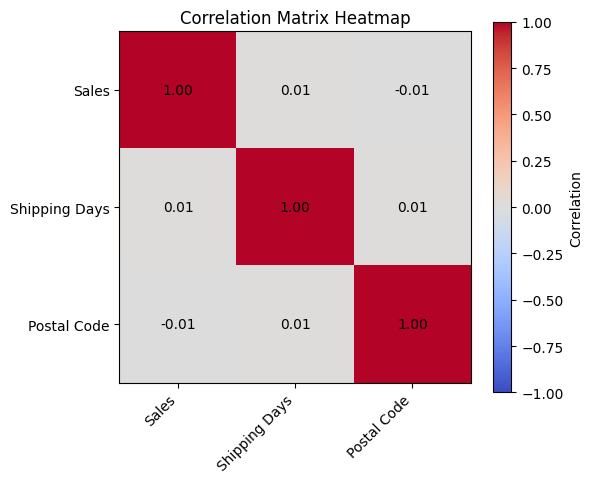

In [32]:
import matplotlib.pyplot as plt

corr = df_reduced[["Sales", "Shipping Days", "Postal Code"]].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()